# Payne Zero from stellar labels to observed spectra

This notebook builds one forward-modeling workflow in small steps. We first make a fast spectrum directly from stellar labels. We then run the atmosphere solver and synthesize from its converged output. Later sections add an instrument model, fit a mock spectrum, calibrate an atomic line against a solar FTS atlas, and model an APOGEE spectrum.

The examples use short wavelength intervals so they remain practical on a laptop. CUDA is preferred for wide production windows, Apple Metal provides a useful local path, and every calculation also supports a CPU.


In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import torch

repo = Path.cwd().resolve()
output_dir = repo / "tutorial_output"
output_dir.mkdir(exist_ok=True)
os.environ.setdefault(
    "PAYNE_ZERO_SYNTHESIS_CACHE_DIR",
    str(output_dir / "synthesis_source_cache"),
)
os.environ.setdefault(
    "PAYNE_ZERO_NUMBA_CACHE_DIR",
    str(output_dir / "numba_cache"),
)


'/Users/ysting/payne-zero/tutorial_output/numba_cache'

Choose one device once and reuse it throughout the workflow. `auto` selects CUDA first, then Apple Metal, then the CPU. GPU calculations use single precision; the CPU path uses double precision.


In [2]:
requested = os.getenv("PAYNE_ZERO_DEVICE", "auto")
if requested == "auto":
    device = (
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available()
        else "cpu"
    )
else:
    device = requested

dtype_name = "float64" if device == "cpu" else "float32"
torch_dtype = torch.float64 if dtype_name == "float64" else torch.float32
print(f"device={device}, dtype={dtype_name}")


device=mps, dtype=float32


The plotting defaults below are used by every figure. They do not affect the physical calculation.


In [3]:
COLORS = {
    "black": "#111827",
    "navy": "#1B4965",
    "blue": "#0072B2",
    "orange": "#D55E00",
    "green": "#009E73",
    "grey": "#6B7280",
    "uncertainty": "#B8CCE0",
}
plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 10.5,
    "axes.labelsize": 10.5,
    "legend.fontsize": 9.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.55,
    "xtick.direction": "out",
    "ytick.direction": "out",
})


## 1. Fast synthesis directly from stellar labels

`synthesize_from_labels` is the usual entry point when you want a spectrum and do not already have an atmosphere file. It predicts a suitable starting atmosphere from the labels and immediately runs synthesis. It does not iterate the atmosphere equations, which makes this path useful for exploration and repeated trial spectra.

The first example uses the compact five-label initializer with solar labels.


In [4]:
from payne_zero_synthesis import synthesize_from_labels

solar_labels = dict(
    effective_temperature=5777.0,
    log_surface_gravity=4.44,
    metallicity=0.0,
    alpha_enhancement=0.0,
    microturbulence_km_s=1.0,
)
spectral_window = dict(
    wavelength_start_nm=500.0,
    wavelength_end_nm=502.0,
    r_grid=60_000,
    device=device,
    dtype=dtype_name,
)
fast_spectrum = synthesize_from_labels(**solar_labels, **spectral_window)
print(f"fast spectrum: {fast_spectrum.wavelength_nm.size} pixels")
print("workflow: stellar labels -> initialized atmosphere -> synthesis")


fast spectrum: 240 pixels
workflow: stellar labels -> initialized atmosphere -> synthesis


The returned object contains wavelength, total flux, continuum flux, normalized flux, timing, and the initialized atmosphere. Change the chemical arguments to select another initializer:

| Family | Arguments | Use when |
|---|---|---|
| Five label | `metallicity`, `alpha_enhancement` | A compact search is sufficient |
| Eight label | Add `c_over_m`, `n_over_m`, `o_over_m` | C, N, and O must vary independently |
| Direct abundance | Set `initializer_family="direct_abundance"`, `fe_over_h`, and `x_over_h={"Mg": ..., ...}` | Individual `[X/H]` values define the mixture |

The direct-abundance family requires its optional initializer checkpoint. All three families return the same spectrum fields, so later instrument and fitting code is unchanged.


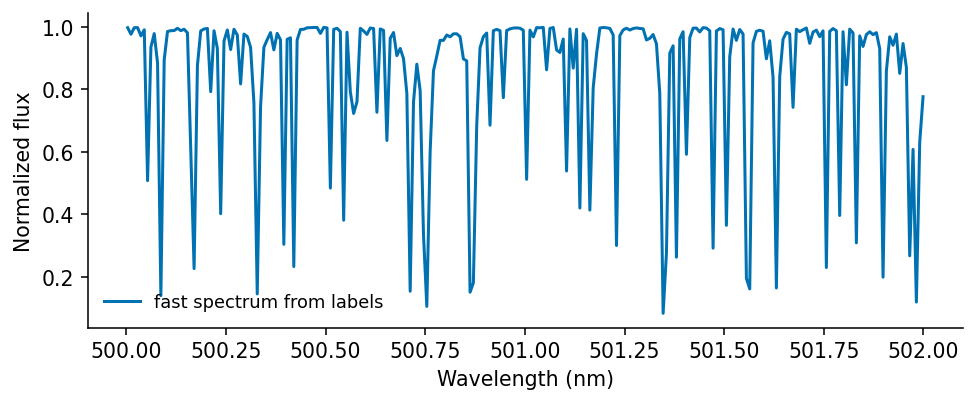

In [5]:
fig, ax = plt.subplots(figsize=(7.1, 3.0))
ax.plot(
    fast_spectrum.wavelength_nm,
    fast_spectrum.normalized_flux,
    color=COLORS["blue"],
    label="fast spectrum from labels",
)
ax.set(xlabel="Wavelength (nm)", ylabel="Normalized flux")
ax.legend(loc="lower left", frameon=False)
fig.tight_layout()
plt.show()


## 2. Converge an atmosphere, then synthesize

Use the full path when the retained spectrum must come from an atmosphere that satisfies the physical convergence tests at the requested labels and abundances. This is normally the final calculation after a fast search, or the starting point for work that depends directly on the atmospheric structure.

The first step is `solve_structured_atmosphere`. The notebook loads a bundled converged solar atmosphere by default so it remains quick. Set `PAYNE_ZERO_RUN_ATMOSPHERE=1` before execution to repeat the solve.


In [6]:
from payne_zero_atmosphere import solve_structured_atmosphere

atmosphere_path = repo / "examples" / "data" / "sun_structured_atmosphere.npz"
if os.getenv("PAYNE_ZERO_RUN_ATMOSPHERE", "0") == "1":
    atmosphere_path = solve_structured_atmosphere(
        **solar_labels,
        out_dir=output_dir / "solar_atmosphere",
    )
print("converged atmosphere:", atmosphere_path.name)


converged atmosphere: sun_structured_atmosphere.npz


The second step is `synthesize`, which reads the converged atmosphere and computes the spectrum on the requested wavelength grid. An atmosphere solved in another run is used in exactly the same way.


In [7]:
from payne_zero_synthesis import synthesize

physical_sun = synthesize(
    atmosphere_path,
    wavelength_start_nm=500.0,
    wavelength_end_nm=502.0,
    resolution=60_000,
    device=device,
    dtype=dtype_name,
)
print(f"physical spectrum: {physical_sun.wavelength_nm.size} pixels")
print("workflow: converged atmosphere -> synthesis")


physical spectrum: 240 pixels
workflow: converged atmosphere -> synthesis


The two workflows differ in purpose. Use `synthesize_from_labels` when many fast trial spectra are needed. Use `solve_structured_atmosphere` followed by `synthesize` when the accepted result must include a newly converged atmosphere. The remaining sections use the converged solar spectrum so every instrument operation begins from a complete physical calculation.


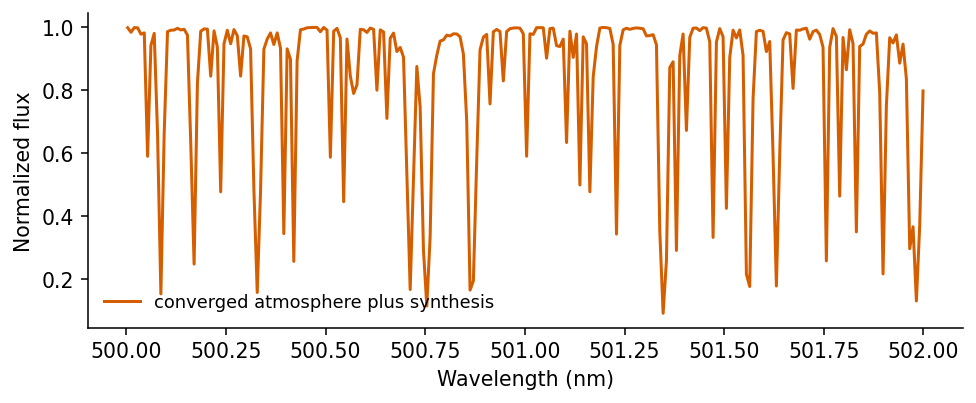

In [8]:
fig, ax = plt.subplots(figsize=(7.1, 3.0))
ax.plot(
    physical_sun.wavelength_nm,
    physical_sun.normalized_flux,
    color=COLORS["orange"],
    label="converged atmosphere plus synthesis",
)
ax.set(xlabel="Wavelength (nm)", ylabel="Normalized flux")
ax.legend(loc="lower left", frameon=False)
fig.tight_layout()
plt.show()


## 3. Map an intrinsic spectrum to observed pixels

Synthesis returns total and continuum flux on a uniform logarithmic wavelength grid. A reduced observation instead lives on detector pixels and includes a radial-velocity shift, stellar or residual broadening, and an instrumental line-spread function. These operations must be applied consistently before the model is sampled at the observed wavelengths.

`ObservedSpectrumOperator` performs this complete projection on the same Torch device as synthesis. It convolves total and continuum flux separately and normalizes only afterward, which avoids treating a varying continuum as part of the line-spread function. The example uses a constant resolving power. A sampled shift-invariant LSF can instead be passed as one odd-length kernel whose middle entry is zero offset and whose sample spacing is one native log-wavelength pixel. Section 6 replaces it with APOGEE's wavelength-dependent LSF through the same `convolve_fluxes` interface.


In [9]:
from fitter import ObservedSpectrumOperator

observed_wavelength = np.linspace(
    physical_sun.wavelength_nm[4],
    physical_sun.wavelength_nm[-5],
    115,
)
instrument = ObservedSpectrumOperator(
    physical_sun.wavelength_nm,
    observed_wavelength,
    resolving_power=25_000,
    device=device,
    dtype=torch_dtype,
)
instrument.set_parameters(
    radial_velocity_km_s=2.0,
    broadening_sigma_km_s=3.0,
)


`convolve_fluxes` applies the velocity shift, broadening, line-spread function, and detector sampling in one device-resident operation. Total and continuum flux are carried separately so normalization occurs after convolution.


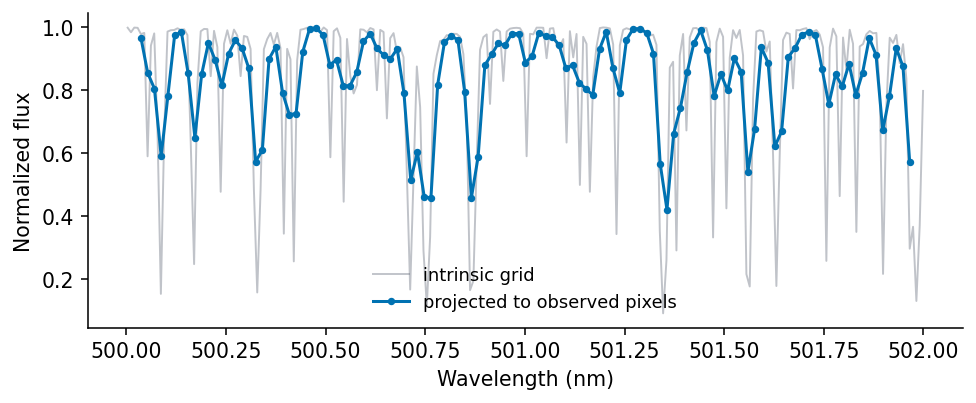

In [10]:
projected_total, projected_continuum, projected_normalized = (
    instrument.convolve_fluxes(
        torch.as_tensor(
            physical_sun.flux_total, device=device, dtype=torch_dtype
        ),
        torch.as_tensor(
            physical_sun.flux_continuum, device=device, dtype=torch_dtype
        ),
    )
)
projected_normalized = projected_normalized.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(7.1, 3.0))
ax.plot(
    physical_sun.wavelength_nm,
    physical_sun.normalized_flux,
    color=COLORS["grey"],
    alpha=0.42,
    linewidth=1.0,
    label="intrinsic grid",
)
ax.plot(
    observed_wavelength,
    projected_normalized,
    color=COLORS["blue"],
    marker="o",
    ms=2.8,
    label="projected to observed pixels",
)
ax.set(xlabel="Wavelength (nm)", ylabel="Normalized flux")
ax.legend(loc="lower center", frameon=False)
fig.tight_layout()
plt.show()


## 4. Recover a label from a mock spectrum

A spectral fitter needs three pieces: the observed flux and uncertainty, bounds for the labels being varied, and a callback that returns the forward model at a proposed label vector. Here both the mock observation and every trial spectrum come directly from `synthesize_from_labels` followed by the instrument operator from Section 3. No label-to-flux emulator enters the fit.

The callback below varies `[M/H]`. The fitter measures a local spectral response with finite differences, proposes a bounded label update, and repeats until the objective no longer improves. Extending the fit to several labels changes the parameter vector and response steps, not the forward-model interface.

This controlled example is already continuum normalized, so no continuum coefficients are fitted. For a reduced spectrum, pass a low-order basis through `continuum_basis`; those linear coefficients are then profiled at every nonlinear trial.


In [11]:
from fitter import (
    FitConfiguration,
    NormalizedSpectrum,
    fit_normalized_spectrum,
)

mock_common = dict(
    effective_temperature=4750.0,
    log_surface_gravity=2.5,
    alpha_enhancement=0.15,
    microturbulence_km_s=1.5,
    wavelength_start_nm=515.0,
    wavelength_end_nm=517.0,
    r_grid=30_000,
    device=device,
    dtype=dtype_name,
)
native_template = synthesize_from_labels(metallicity=-0.3, **mock_common)
mock_wavelength = np.linspace(
    native_template.wavelength_nm[3],
    native_template.wavelength_nm[-4],
    120,
)
mock_instrument = ObservedSpectrumOperator(
    native_template.wavelength_nm,
    mock_wavelength,
    resolving_power=25_000,
    device=device,
    dtype=torch_dtype,
)


A model callback turns one trial parameter vector into flux on the observed pixels. Here the only free label is `[M/H]`; the instrument operator is reused at every trial.


In [12]:
def metallicity_model(parameters):
    return synthesize_from_labels(
        metallicity=float(parameters[0]),
        spectral_operator=mock_instrument,
        **mock_common,
    ).normalized_flux


We now create a mock observation at a known metallicity and add Gaussian noise. `NormalizedSpectrum` stores the wavelengths, fluxes, inverse variances, and valid-pixel mask expected by the fitter.


In [13]:
truth_metallicity = -0.30
noiseless_mock = metallicity_model(np.array([truth_metallicity]))
rng = np.random.default_rng(20260724)
sigma = 1.0 / 400.0
observed_mock = noiseless_mock + rng.normal(0.0, sigma, noiseless_mock.size)
mock_data = NormalizedSpectrum(
    wavelength=mock_wavelength,
    flux=observed_mock,
    inverse_variance=np.full(mock_wavelength.size, sigma**-2),
    mask=np.ones(mock_wavelength.size, dtype=bool),
)


`FitConfiguration` names the free coordinate and supplies its starting value, bounds, finite-difference step, and trust width. The optimizer then calls the physical forward model until the objective no longer improves.


In [14]:
fit_config = FitConfiguration(
    names=("M_H",),
    initial=np.array([-0.05]),
    lower=np.array([-1.0]),
    upper=np.array([0.3]),
    derivative_steps=np.array([0.05]),
    trust_half_width=np.array([0.30]),
    maximum_iterations=4,
)
mock_fit = fit_normalized_spectrum(
    mock_data,
    fit_config,
    metallicity_model,
)
print(f"truth [M/H] = {truth_metallicity:+.3f}")
print(f"fitted [M/H] = {mock_fit.parameters[0]:+.3f}")
print(f"stop = {mock_fit.stop_reason}")


truth [M/H] = -0.300
fitted [M/H] = -0.295
stop = line_search


The upper panel compares the recovered spectrum with the noisy mock observation. The lower panel shows data minus model together with the known one-sigma noise band. Residuals that fluctuate within this band indicate that the recovered spectrum explains the mock data to the injected precision.


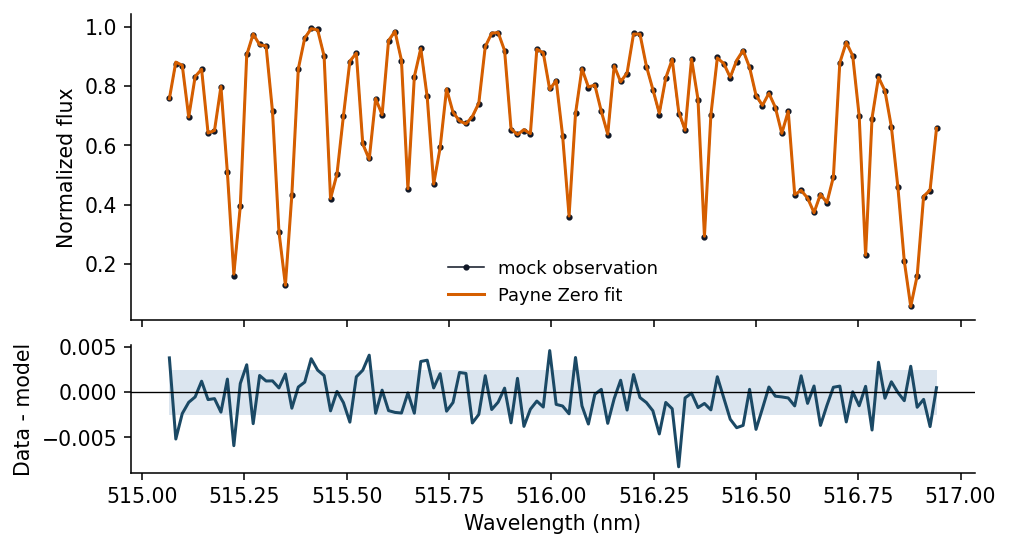

In [15]:
fit_residual = observed_mock - mock_fit.model_flux
fig, (top, bottom) = plt.subplots(
    2,
    1,
    figsize=(7.1, 3.8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.4, 1.0]},
    constrained_layout=True,
)
top.plot(
    mock_wavelength,
    observed_mock,
    color=COLORS["black"],
    marker="o",
    markersize=2.2,
    linewidth=0.8,
    label="mock observation",
)
top.plot(
    mock_wavelength,
    mock_fit.model_flux,
    color=COLORS["orange"],
    label="Payne Zero fit",
)
bottom.plot(mock_wavelength, fit_residual, color=COLORS["navy"])
bottom.fill_between(
    mock_wavelength,
    -sigma,
    sigma,
    color=COLORS["uncertainty"],
    alpha=0.5,
    linewidth=0,
    label="1 sigma uncertainty",
)
bottom.axhline(0.0, color="black", lw=0.7)
top.set_ylabel("Normalized flux")
bottom.set(xlabel="Wavelength (nm)", ylabel="Data - model")
top.legend(
    loc="lower center",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.9,
)
plt.show()


## 5. Calibrate an atomic line with a real FTS spectrum

A line-list calibration asks whether a mismatch can be reduced by changing an atomic parameter rather than a stellar label. The standard-star atmosphere, wavelength registration, broadening, and all unselected opacity remain fixed. The optimizer differentiates the synthesized flux with respect to the selected atomic parameters and updates them jointly with the transfer calculation.

The bundled example uses the Livingston and Wallace solar Fourier-transform-spectrometer atlas and one Fe I transition at 1568.180 nm. It begins from the unmodified catalog value and fits a single additive correction to `log(gf)`, the logarithmic oscillator strength that controls the line opacity. The expensive background opacity is prepared once; each optimizer step recalculates only the selected transition and the emergent spectrum.


In [16]:
from linelist_calibration import calibrate_line_parameters
from linelist_calibration.examples.fit_solar_fts_line import build_example

fts_data, fts_config, fts_model, fts_metadata = build_example(
    device=device,
    dtype=dtype_name,
    maximum_iterations=30,
)
fts_callback = fts_model.callback(("loggf",))
fts_baseline = fts_model.baseline_flux(("loggf",))


The callback exposes only the selected atomic parameter. The optimizer updates that parameter, while the atmosphere and all other catalog entries remain fixed.


In [17]:
fts_result = calibrate_line_parameters(
    fts_data,
    fts_config,
    fts_callback,
)
fitted_tensor = torch.as_tensor(
    fts_result.values,
    device=fts_model.device,
    dtype=fts_model.dtype,
)
with torch.no_grad():
    fts_calibrated = fts_callback(fitted_tensor).detach().cpu().numpy()


Export the fitted value as a source-bound overlay. Applying this overlay later changes the selected transition without replacing the user's base catalog.


In [18]:
fts_overlay = fts_model.write_atomic_calibration_overlay(
    fts_result.values,
    output_dir / "solar_fts_fe_line_overlay.npz",
    parameter_families=("loggf",),
    calibration_name="tutorial_solar_fts_fe_line",
)
residual_power_reduction = 1.0 - (
    fts_result.final_loss / fts_result.initial_loss
)
print("atlas:", fts_metadata["atlas"])
print("transition:", fts_model.transitions[0].name)
print(f"fitted delta log(gf) = {fts_result.values[0]:+.3f} dex")
print(f"full-window residual-power reduction = {100 * residual_power_reduction:.1f}%")
print("overlay:", fts_overlay["overlay_path"])


atlas: Livingston & Wallace (1991) solar center-of-disk infrared atlas
transition: Fe I 1568.180 nm
fitted delta log(gf) = +0.801 dex
full-window residual-power reduction = 78.5%
overlay: /Users/ysting/payne-zero/tutorial_output/solar_fts_fe_line_overlay.npz


The saved overlay records the transition identity and its additive correction in dex. A production calibration can optimize several linked transitions and the damping families `vdw`, `radiative`, and `stark`. To use another standard star, supply its converged atmosphere, observed wavelength and flux arrays, objective weights, velocity registration, and broadening or LSF kernel. Several standards can share one set of atomic corrections.


In [19]:
fts_wavelength = fts_model.output_wavelength_nm
fts_observed = np.asarray(fts_data.flux)
fts_delta_pm = 1000.0 * (
    fts_wavelength - fts_model.transitions[0].wavelength_nm
)
line_core = np.abs(fts_delta_pm) <= 30.0
core_initial = np.sum(
    fts_data.weight[line_core]
    * (fts_observed[line_core] - fts_baseline[line_core]) ** 2
)
core_final = np.sum(
    fts_data.weight[line_core]
    * (fts_observed[line_core] - fts_calibrated[line_core]) ** 2
)
core_reduction = 1.0 - core_final / core_initial
print(f"line-core residual-power reduction = {100 * core_reduction:.1f}%")


line-core residual-power reduction = 99.4%


The upper panel shows the observed and synthesized line profiles. The lower panel keeps a residual comparison because the purpose of calibration is to reduce this specific mismatch.


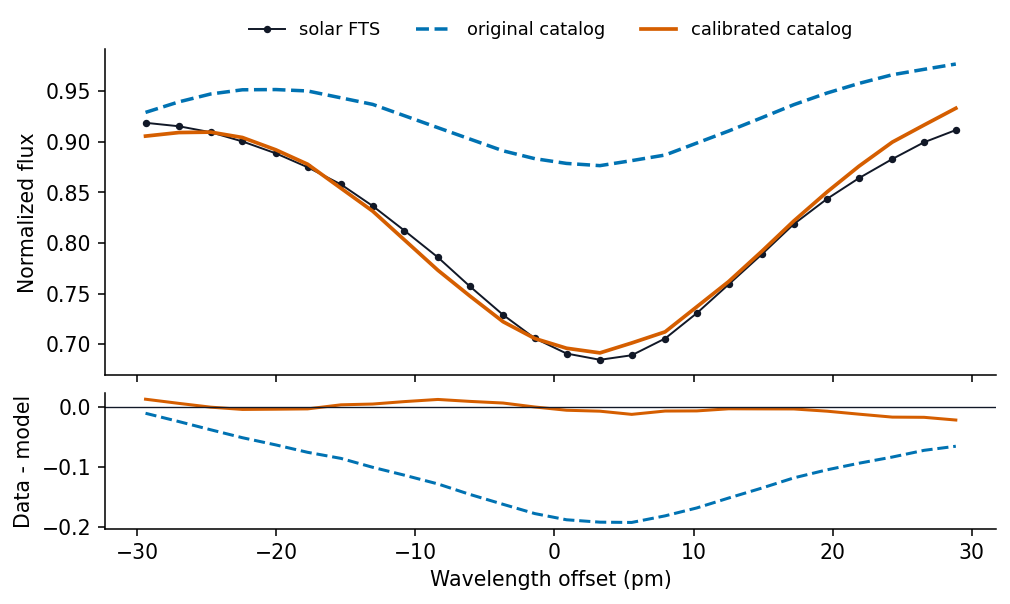

In [20]:
fig, (top, bottom) = plt.subplots(
    2,
    1,
    figsize=(7.1, 4.2),
    sharex=True,
    gridspec_kw={"height_ratios": [2.4, 1.0]},
    constrained_layout=True,
)
top.plot(
    fts_delta_pm[line_core],
    fts_observed[line_core],
    color=COLORS["black"],
    marker="o",
    markersize=2.8,
    linewidth=1.0,
    label="solar FTS",
)
top.plot(
    fts_delta_pm[line_core],
    fts_baseline[line_core],
    color=COLORS["blue"],
    linestyle="--",
    linewidth=1.8,
    label="original catalog",
)
top.plot(
    fts_delta_pm[line_core],
    fts_calibrated[line_core],
    color=COLORS["orange"],
    linewidth=1.9,
    label="calibrated catalog",
)
bottom.plot(
    fts_delta_pm[line_core],
    (fts_observed - fts_baseline)[line_core],
    color=COLORS["blue"],
    linestyle="--",
    label="original residual",
)
bottom.plot(
    fts_delta_pm[line_core],
    (fts_observed - fts_calibrated)[line_core],
    color=COLORS["orange"],
    label="calibrated residual",
)
bottom.axhline(0.0, color=COLORS["black"], lw=0.7)
top.set_ylabel("Normalized flux")
bottom.set(xlabel="Wavelength offset (pm)", ylabel="Data - model")
top.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=False,
    borderaxespad=0.0,
)
plt.show()


## 6. APOGEE with a wavelength-dependent LSF and continuum

A survey adapter supplies the observational details that are absent from an intrinsic spectrum. APOGEE uses a wavelength-dependent line-spread function, so the constant-resolution operator from Section 3 is replaced by tabulated kernels across the detector. The adapter applies those kernels on the selected device.

The forward model also fits a residual velocity, effective Gaussian broadening, and one low-order continuum per detector segment. This keeps the stellar and observational parameters in one calculation while comparing every trial with the reduced spectrum on its native pixels.

Begin by loading one public DR14 spectrum and its uncertainty, mask, metadata, and retained reference fit.


In [21]:
from fitter.apogee import fit_apogee_spectrum

with np.load(repo / "examples" / "data" / "apogee_dr14_example.npz") as source:
    apogee = {name: np.asarray(source[name]) for name in source.files}
apogee_metadata = json.loads(
    (repo / "examples" / "data" / "apogee_dr14_example.json").read_text()
)
with np.load(
    repo / "examples" / "data" / "apogee_dr14_fit_reference.npz"
) as source:
    apogee_reference = {
        name: np.asarray(source[name]) for name in source.files
    }
apogee_model = apogee_reference["normalized_model_flux"]
print("APOGEE object:", apogee_metadata["object_id"])


APOGEE object: 2M08002084+4044415


`fit_apogee_spectrum` accepts arrays rather than a survey-specific file object. Replace these arrays and the instrument adapter to fit another survey. The default notebook uses the retained fit so it opens quickly. Set `PAYNE_ZERO_RUN_APOGEE=1` to run the optimization and plot that new result instead.


In [22]:
if os.getenv("PAYNE_ZERO_RUN_APOGEE", "0") == "1":
    apogee_result_dir = output_dir / "apogee_fit"
    reference_labels = np.array([
        apogee_metadata[name] for name in (
            "effective_temperature",
            "log_surface_gravity",
            "metallicity",
            "alpha_enhancement",
            "microturbulence_km_s",
        )
    ])
    fit_summary = fit_apogee_spectrum(
        apogee_result_dir,
        object_id=apogee_metadata["object_id"],
        wavelength_nm=apogee["wavelength_nm"],
        normalized_flux=apogee["normalized_flux"],
        inverse_variance=apogee["inverse_variance"],
        good_pixel_mask=apogee["good_pixel_mask"],
        reference_labels=reference_labels,
        reference_vmacro_km_s=apogee_metadata[
            "macroscopic_broadening_km_s"
        ],
        atomic_calibration_path=(
            repo
            / "linelist_calibration"
            / "data"
            / "sun_arcturus_fts_hband_shared.npz"
        ),
        device=device,
        dtype=dtype_name,
        compact_trace=False,
        force=True,
    )
    with np.load(apogee_result_dir / "optimization_trace.npz") as trace:
        apogee_model = trace["normalized_model_flux"][
            fit_summary["selected_evaluation"]
        ]


The upper panel compares the reduced APOGEE spectrum with the continuum-profiled and LSF-convolved model over a line-rich interval. The orange curve is evaluated on exactly the observed pixels.

The lower panel shows data minus model with the reported one-sigma flux uncertainty. This directly checks the complete observed-frame calculation without adding a separate LSF diagnostic plot.


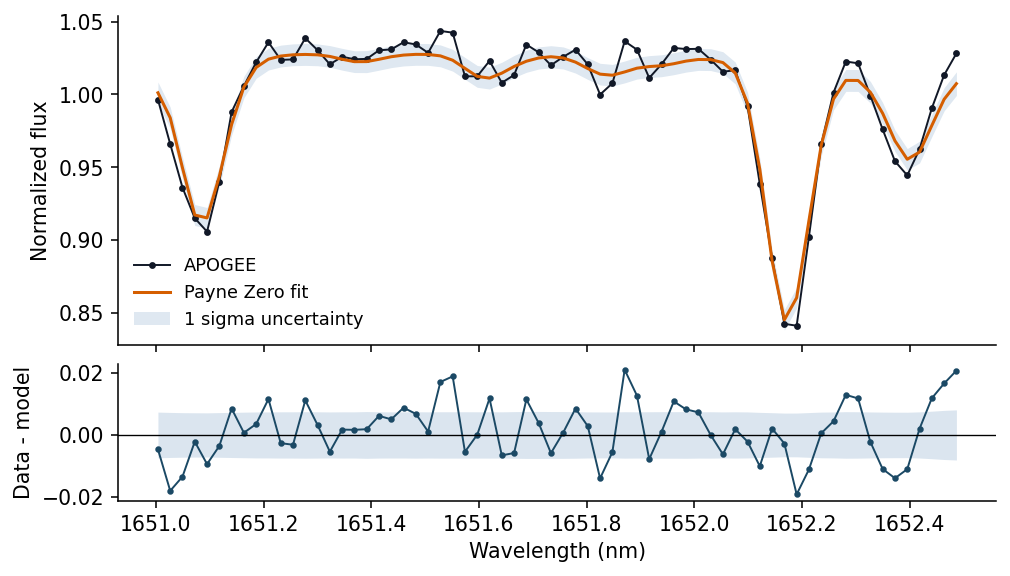

In [23]:
wavelength = apogee["wavelength_nm"]
observed = apogee["normalized_flux"]
error = apogee["normalized_error"]
good = apogee["good_pixel_mask"]
region = (wavelength > 1651.0) & (wavelength < 1652.5) & good

fig, (top, bottom) = plt.subplots(
    2, 1, figsize=(7.1, 4.0), sharex=True,
    gridspec_kw={"height_ratios": [2.4, 1.0]},
    constrained_layout=True,
)
top.plot(
    wavelength[region],
    observed[region],
    color=COLORS["black"],
    marker="o",
    markersize=2.5,
    linewidth=1.0,
    label="APOGEE",
)
top.plot(
    wavelength[region],
    apogee_model[region],
    color=COLORS["orange"],
    label="Payne Zero fit",
)
top.fill_between(
    wavelength[region],
    apogee_model[region] - error[region],
    apogee_model[region] + error[region],
    color=COLORS["uncertainty"],
    alpha=0.45,
    linewidth=0,
    label="1 sigma uncertainty",
)
residual = observed[region] - apogee_model[region]
bottom.plot(
    wavelength[region],
    residual,
    color=COLORS["navy"],
    marker="o",
    markersize=2.3,
    linewidth=1.0,
    label="data minus model",
)
bottom.fill_between(
    wavelength[region],
    -error[region],
    error[region],
    color=COLORS["uncertainty"],
    alpha=0.5,
    linewidth=0,
    label="1 sigma uncertainty",
)
bottom.axhline(0.0, color="black", lw=0.7)
top.set_ylabel("Normalized flux")
bottom.set(xlabel="Wavelength (nm)", ylabel="Data - model")
top.legend(loc="lower left", frameon=False)
plt.show()


## 7. Adapting the workflow

The two core entry points cover most uses. Call `synthesize_from_labels` for fast trial spectra. Call `solve_structured_atmosphere` and then `synthesize` when the retained result needs a converged atmosphere.

To fit another reduced spectrum, replace the wavelength, flux, uncertainty, mask, and instrument operator. A constant-resolution or sampled shift-invariant LSF can use `ObservedSpectrumOperator`. A wavelength-dependent LSF implements `output_wavelength_nm` and `convolve_fluxes(total_flux, continuum_flux)`. Supply a low-order basis when the reduction still requires continuum profiling.

To calibrate another standard star, construct `SynthesisLineCalibrationModel` with its converged atmosphere and atlas arrays. Select the transitions and atomic parameter families, optimize them, and export an overlay or substituted local catalog. Several standards can share one correction.

These replaceable boundaries keep the common workflow short while allowing a new abundance parameterization, standard star, instrument, or survey to use the same atmosphere, synthesis, calibration, and fitting interfaces.
